In [1]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import torch
from tqdm.auto import tqdm

import grouping_trainer as gt
import utils

In [2]:
sns.set_theme(style="darkgrid")

In [3]:
SAMPLE_VAL: int | None = None if torch.cuda.is_available() else 1_000

In [4]:
def evaluate_models(
    model_paths: tuple[str, ...],
    evaluator: gt.evaluator.MinPrecisionEvaluator,
):
    model_to_result: dict[str, dict[str, float]] = {}
    for model_path in tqdm(model_paths, desc="Evaluating models"):
        model = gt.utils.SentenceTransformer(str(model_path), trust_remote_code=True)
        model_to_result[model_path] = evaluator(model)
    return model_to_result


def plot(
    model_to_result: dict[str, dict[str, float]],
    evaluator: gt.evaluator.MinPrecisionEvaluator,
):
    """
    For each precision level, plot the dimension vs recall.
    """
    # Flatten / normalize the data
    records = []
    for model_path, result in model_to_result.items():
        for metric_name, metric_value in result.items():
            dim, precision, metric_name = evaluator.parse_metric_name(metric_name)
            records.append(
                {
                    "model": model_path.split("/")[-1],
                    "dim": dim,
                    "precision": precision,
                    "metric": metric_name,
                    "value": metric_value,
                }
            )
    df = pl.DataFrame(records)

    recall_df = df.filter(pl.col("metric") == "recall")
    threshold_df = df.filter(pl.col("metric") == "threshold")

    # Get unique precision levels and dimensions
    precisions = sorted(recall_df["precision"].unique().to_list())
    dimensions = sorted(recall_df["dim"].unique().to_list())
    num_precisions = len(precisions)

    # Create subplots - one for each precision level
    fig, axes = plt.subplots(1, num_precisions, figsize=(5 * num_precisions, 4), sharey=True)
    if num_precisions == 1:
        axes = [axes]
    axes: list[plt.Axes] = list(axes)

    for ax, precision in zip(axes, precisions, strict=True):
        recall_data = recall_df.filter(pl.col("precision") == precision)
        threshold_data = threshold_df.filter(pl.col("precision") == precision)
        sns.lineplot(data=recall_data.to_pandas(), x="dim", y="value", hue="model", marker="o", ax=ax)

        # Annotate each point with threshold
        for row in threshold_data.iter_rows(named=True):
            recall_row = recall_data.filter((pl.col("model") == row["model"]) & (pl.col("dim") == row["dim"]))
            if len(recall_row) > 0:
                recall_val = recall_row["value"][0]
                ax.annotate(
                    f"{row['value']:.2f}",
                    (row["dim"], recall_val),
                    textcoords="offset points",
                    xytext=(0, 5),
                    ha="center",
                    fontsize=7,
                )

        ax.set_title(f"Precision ≈ {precision:.0%}")
        ax.set_xlabel("Dimension")
        ax.set_ylabel("Recall")
        ax.set_xticks(dimensions)
        ax.legend().remove()

    # Single legend for the whole figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Model", loc="outside right upper", fontsize="small")
    fig.suptitle("Model comparison")

    plt.tight_layout()

In [5]:
model_paths = (
    "/Users/kdubey/projects/seer/models/issue_grouping_v1/embeddings",
    "checkpoint-451",
)

In [6]:
dataset_val = gt.train.df_to_dataset(utils.load_val_df(sample_size=SAMPLE_VAL))
len(dataset_val)

1000

In [7]:
evaluator = gt.evaluator.MinPrecisionEvaluator(
    sentences1=list(dataset_val["query_stacktrace_string"]),
    sentences2=list(dataset_val["candidate_stacktrace_string"]),
    labels=[int(record["label"]) for record in dataset_val],
    name="val",
    show_progress_bar=True,
    batch_size=1,
    min_predictions=100,
    truncate_dims=(64, 128, 256, 512, 768),
)

In [8]:
model_to_result = evaluate_models(model_paths, evaluator)

Evaluating models:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/kdubey/projects/grouping-trainer/.venv/lib/python3.13/site-packages/torch/onnx/_internal/registration.py:162: OnnxExporterWarning: Symbolic function 'aten::scaled_dot_product_attention' already registered for opset 14. Replacing the existing function with new function. This is unexpected. Please report it on https://github.com/pytorch/pytorch/issues.
  warnings.warn(


Batches:   0%|          | 0/1876 [00:00<?, ?it/s]

Batches:   0%|          | 0/1876 [00:00<?, ?it/s]

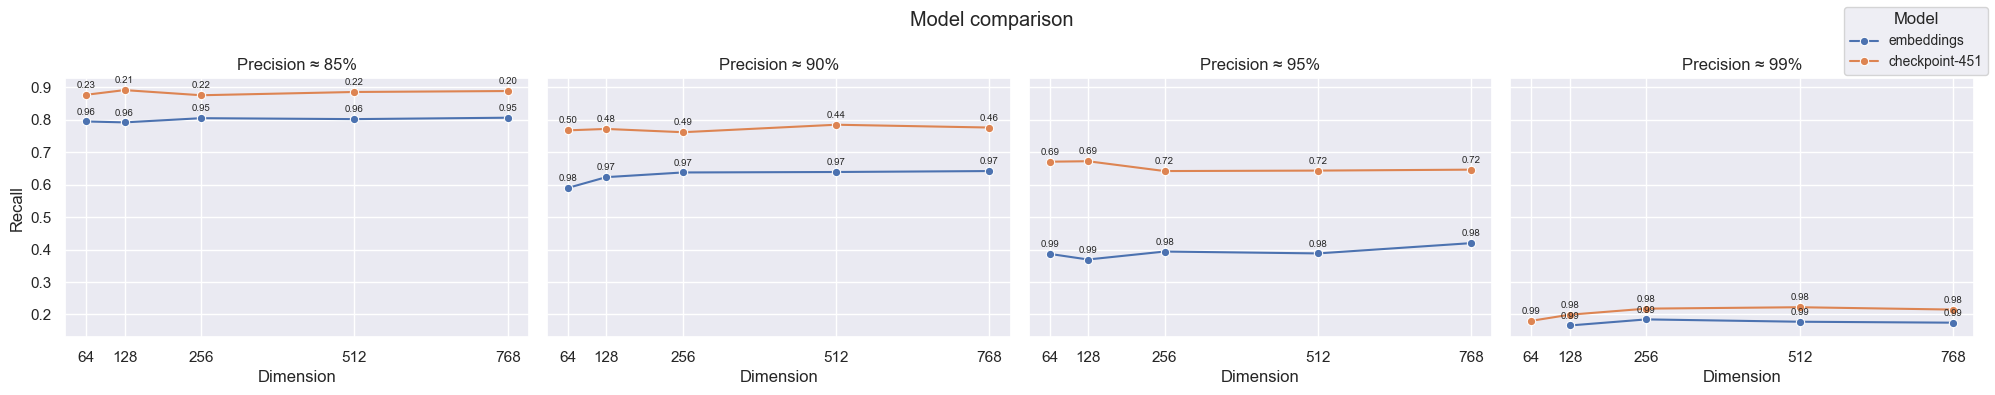

In [9]:
plot(model_to_result, evaluator)